# Лабораторная работа 2

Не забудьте скопировать ноутбук!!!

*Дорогие, задание сделано с любовью, и чтобы развить понимание O-символики и понять как вообще работают и измеряются алгоритмы. Если что-то будет не ясно, пишите в чат и мы вам поможем!*

Дисциплина: АиСД

Студент: Даньшина Василиса Ивановна

Группа: база

## 1. Цель работы

Цель КДЗ — экспериментально определить временную сложность различных алгоритмов сортировки в лучшем/среднем и худших случаях, выполнить сравнение для разных типов входных массивов и проанализировать полученные графики.

## 2. Рассматриваемые алгоритмы сортировки

1. Сортировка выбором

2. Пузырьковая (в лучше случае должно быть O(n) в этой реализации)

3. Простые вставки

4. Сортировка подсчётом (устойчивая)

5. Сортировка слиянием

6. Быстрая сортировка (опорный — первый элемент, разбиание Хоара)

7. Пирамидальная сортировка

8. Сортировка Шелла (последовательность Циура)

9. *** TimSort

Сделайте функции для сортировок, учтите, что нужно будет сделать функции дважды:
* для измерения времени
* и для измерения количества элементарных операций

In [ ]:
import random
import timeit
import pandas as pd
import matplotlib.pyplot as plt
import os

random.seed(42)


###Алгоритмы сортировки (версии для измерения времени)

In [ ]:
# Сортировка выбором
def selection_sort(arr):
    n = len(arr)
    for i in range(n):
        min_idx = i
        for j in range(i+1, n):
            if arr[j] < arr[min_idx]:
                min_idx = j
        arr[i], arr[min_idx] = arr[min_idx], arr[i]

In [ ]:
# Пузырьковая сортировка
def bubble_sort(arr):
    n = len(arr)
    for i in range(n):
        swapped = False
        for j in range(0, n - i - 1):
            if arr[j] > arr[j+1]:
                arr[j], arr[j+1] = arr[j+1], arr[j]
                swapped = True
        if not swapped:
            break

In [ ]:
# Сортировка вставками
def insertion_sort(arr):
    for i in range(1, len(arr)):
        key = arr[i]
        j = i - 1
        while j >= 0 and arr[j] > key:
            arr[j+1] = arr[j]
            j -= 1
        arr[j+1] = key

In [ ]:
# Сортировка подсчетом
def counting_sort(arr):
    if not arr:
        return
    max_val = max(arr); min_val = min(arr)
    offset = min_val
    count = [0] * (max_val - min_val + 1)
    for x in arr:
        count[x - offset] += 1
    idx = 0
    for i, c in enumerate(count):
        for _ in range(c):
            arr[idx] = i + offset; idx += 1

In [ ]:
# Сортировка слиянием
def merge_sort(arr):
    if len(arr) <= 1:
        return
    mid = len(arr) // 2
    left = arr[:mid]; right = arr[mid:]
    merge_sort(left); merge_sort(right)
    i = j = k = 0
    while i < len(left) and j < len(right):
        if left[i] <= right[j]:
            arr[k] = left[i]; i += 1
        else:
            arr[k] = right[j]; j += 1
        k += 1
    while i < len(left):
        arr[k] = left[i]; i += 1; k += 1
    while j < len(right):
        arr[k] = right[j]; j += 1; k += 1

In [ ]:
# Быстрая сортировка (опорный — первый элемент, разбиание Хоара)
def partition_hoare(arr, low, high):
    pivot = arr[low]
    i = low - 1; j = high + 1
    while True:
        i += 1
        while arr[i] < pivot: i += 1
        j -= 1
        while arr[j] > pivot: j -= 1
        if i >= j:
            return j
        arr[i], arr[j] = arr[j], arr[i]

def quick_sort(arr, low=None, high=None):
    if low is None:
        low, high = 0, len(arr) - 1
    stack = [(low, high)]
    while stack:
        lo, hi = stack.pop()
        if lo < hi:
            p = partition_hoare(arr, lo, hi)
            stack.append((lo, p))
            stack.append((p+1, hi))

In [ ]:
# Пирамидальная сортировка
def heapify(arr, n, i):
    largest = i; l, r = 2*i+1, 2*i+2
    if l < n and arr[l] > arr[largest]: largest = l
    if r < n and arr[r] > arr[largest]: largest = r
    if largest != i:
        arr[i], arr[largest] = arr[largest], arr[i]
        heapify(arr, n, largest)

def heap_sort(arr):
    n = len(arr)
    for i in range(n//2-1, -1, -1):
        heapify(arr, n, i)
    for i in range(n-1, 0, -1):
        arr[0], arr[i] = arr[i], arr[0]
        heapify(arr, i, 0)

In [ ]:
# Сортировка Шелла (последовательность Циура)
def shell_sort(arr):
    n = len(arr)
    gaps = []
    k = 1
    while True:
        if k % 2 == 1:
            g = 9 * (2**k - 2**(k//2)) + 1
        else:
            g = 8 * 2**k - 6 * 2**((k+1)//2) + 1
        if g >= n: break
        gaps.append(g); k += 1
    if not gaps: gaps = [1]
    for gap in reversed(gaps):
        for i in range(gap, n):
            temp = arr[i]; j = i
            while j >= gap and arr[j-gap] > temp:
                arr[j] = arr[j-gap]; j -= gap
            arr[j] = temp

### Алгоритмы с счётчиками элементарных операций

In [ ]:
# Сортировка выбором
def selection_sort_ops(arr):
    ops = 0; n = len(arr); ops +=1
    for i in range(n):
        ops += 1; min_idx = i; ops += 1
        for j in range(i+1, n):
            ops += 1; ops += 1
            if arr[j] < arr[min_idx]:
                min_idx = j; ops += 1
        arr[i], arr[min_idx] = arr[min_idx], arr[i]; ops += 3
    return ops

In [ ]:
# Пузырьковая сортировка
def bubble_sort_ops(arr):
    ops = 0; n = len(arr); ops +=1
    for i in range(n):
        ops += 1; swapped = False; ops += 1
        for j in range(0, n-i-1):
            ops += 1; ops += 4
            if arr[j] > arr[j+1]:
                arr[j], arr[j+1] = arr[j+1], arr[j]; ops += 3
                swapped = True; ops += 1
        ops += 1
        if not swapped: break
    return ops

In [ ]:
# Cортировка вставками
def insertion_sort_ops(arr):
    ops = 0
    for i in range(1, len(arr)):
        ops += 1; key = arr[i]; ops += 1; j = i - 1; ops += 1
        while j >= 0 and arr[j] > key:
            ops += 2; arr[j+1] = arr[j]; ops += 1; j -= 1; ops += 1
        ops += 2; arr[j+1] = key; ops += 1
    return ops

In [ ]:
# Cортировка подсчетом
def counting_sort_ops(arr):
    ops = 0
    if not arr: return 0
    max_val = max(arr); ops += len(arr)
    min_val = min(arr); ops += len(arr)
    offset = min_val; ops += 1
    size = max_val - min_val + 1; ops += 2
    count = [0] * size; ops += size
    for x in arr:
        ops += 1; count[x-offset] += 1; ops += 2
    idx = 0; ops += 1
    for i, c in enumerate(count):
        ops += 1
        for _ in range(c):
            ops += 1; arr[idx] = i+offset; ops += 2; idx += 1; ops += 1
    return ops

In [ ]:
# Cортировка слиянием
def merge_sort_ops(arr):
    ops = [0]
    def merge(a):
        if len(a) <= 1: ops[0] += 1; return
        mid = len(a)//2; ops[0] += 2
        left= a[:mid]; right = a[mid:]; ops[0] += 2
        merge(left); merge(right)
        i = j = k = 0; ops[0] += 3
        while i < len(left) and j < len(right):
            ops[0] += 3
            if left[i] <= right[j]:
                a[k] = left[i]; i += 1; ops[0] += 2
            else:
                a[k] = right[j]; j += 1; ops[0] += 2
            k += 1; ops[0] += 1
        while i < len(left):
            a[k] = left[i]; i += 1; k += 1; ops[0] += 3
        while j < len(right):
            a[k] = right[j]; j += 1; k += 1; ops[0] += 3
    merge(arr)
    return ops[0]

In [ ]:
# Быстрая сортировка
def quick_sort_ops(arr, low=None, high=None, ops=None):
    if ops is None:
        ops = [0]; low, high = 0, len(arr)-1
    stack = [(low, high)]
    while stack:
        lo, hi = stack.pop(); ops[0] += 1
        if lo < hi:
            ops[0] += 1; pivot = arr[lo]; ops[0] +=1
            i = lo - 1; j = hi+1; ops[0] += 2
            while True:
                i += 1; ops[0] += 1
                while arr[i] < pivot: ops[0] += 1; i += 1; ops[0] +=1
                ops[0] += 1
                j -= 1; ops[0] +=1
                while arr[j] > pivot: ops[0] += 1; j -= 1; ops[0] += 1
                ops[0] += 1
                if i >= j: ops[0] += 1; p = j; break
                arr[i], arr[j] = arr[j], arr[i]; ops[0] += 3
            stack.append((lo, p)); stack.append((p+1, hi))
    return ops[0]

In [ ]:
# Пирамидальная сортировка
def heap_sort_ops(arr):
    ops = [0]
    def heapify(a, n, i):
        largest = i; l, r = 2*i+1, 2*i+2; ops[0] += 4
        if l < n and a[l] > a[largest]: largest = l; ops[0] += 3
        if r < n and a[r] > a[largest]: largest = r; ops[0] += 3
        if largest != i:
            ops[0] += 1; a[i], a[largest] = a[largest], a[i]; ops[0] += 3
            heapify(a, n, largest)
    n = len(arr); ops[0] += 1
    for i in range(n//2-1, -1, -1): ops[0] += 1; heapify(arr, n, i)
    for i in range(n-1, 0, -1):
        ops[0] += 1; arr[0], arr[i] = arr[i], arr[0]; ops[0] += 3
        heapify(arr, i, 0)
    return ops[0]

In [ ]:
# Сортировка Шелла
def shell_sort_ops(arr):
    ops = 0; n = len(arr); ops += 1
    gaps = []
    k = 1
    while True:
        if k % 2 == 1: g= 9 * (2**k - 2**(k//2))+1
        else: g = 8 * 2**k - 6 * 2**((k+1)//2)+1
        if g >= n: break
        gaps.append(g); k += 1
    if not gaps: gaps = [1]
    for gap in reversed(gaps):
        ops += 1
        for i in range(gap, n):
            ops += 1; temp = arr[i]; ops += 1; j = i; ops += 1
            while j >= gap and arr[j-gap] > temp:
                ops += 2; arr[j] = arr[j-gap]; ops += 1; j -= gap; ops += 1
            ops += 2; arr[j] = temp; ops += 1
    return ops

## **3. Типы исследуемых массивов**

Для оценки лучшего/худшего/среднего случаев используются различные типы входных массивов (отсортированные, обратно отсортированные, случайные, почти отсортированные). Подумайте, достаточно ли будет тех, что описаны здесь, чтобы оценить наши сортировки.

Возьмите размеры массивов от 100 до 2000 (включительно) с шагом 100.

Для каждого размера массива генерируются 4 вида входных данных:

1. . Случайные числа в диапазоне **[0; 4000]**
2. «Почти отсортированный» массив
3. Отсортированный в обратном порядке массив.

Все эталонные массивы создаются **один раз**, затем для каждой сортировки копируются в рабочий массив (чтобы избежать повторной сортировки отсортированных данных).

In [ ]:
# Генерация массивов
MAX_N = 2000
random.seed(42)

# Случайный массив [0, 4000]
base_random = [random.randint(0, 4000) for _ in range(MAX_N)]

# Обратно отсортированный
base_sorted_rev = list(range(4000, 4000 - MAX_N, -1))

# Почти отсортированный
tmp = list(range(MAX_N))
random.seed(42)
for _ in range(MAX_N // 20):
    i, j = random.randrange(MAX_N), random.randrange(MAX_N)
    tmp[i], tmp[j] = tmp[j], tmp[i]
base_almost_sorted = tmp

array_types = {
    "random":        base_random,
    "reversed":      base_sorted_rev,
    "almost_sorted": base_almost_sorted,
}

print(f"  random = {base_random[:5]}")
print(f"  reversed = {base_sorted_rev[:5]}")
print(f"  almost_sorted = {base_almost_sorted[:5]}")

  random = [2619, 456, 102, 3037, 1126]
  reversed = [4000, 3999, 3998, 3997, 3996]
  almost_sorted = [0, 1, 2, 3, 4]



## **4. Методика измерений**

### **4.1. Измерение времени**

* Для каждого алгоритма и каждой размерности выполняется **20–100 повторов**.
* Используется `timeit`.
* Усреднение производится по всем повторам.
* Время никогда не должно равняться 0 (если так, то что-то сделано не то).

### **4.2. Подсчёт элементарных операций**

В алгоритмы добавлены счётчики сравнений и перестановок.
Сделайте подсчет сложности с помощью подсчета элементарных операций. Надо будет прям в коде сделать счетчики.

Не делайте измерений лишнего. Если засунете в `timeit` и генерацию массива, и копирование, и сортировку, то время будет включать кучу лишних накладных расходов, и разные алгоритмы будут сравниваться не “чисто” по сортировке.

Важно, сравниваем и замеряем только непосредственно сами сортировки.

## **5. Структура эксперимента**

Должна быть какая-то подобная структура эксперимента:

```
для каждого вида массива:
    сгенерировать эталонный массив A
    для каждого алгоритма сортировки:
        для каждой размерности n:
            много раз (k повторов):
                скопировать n элементов A → B
                выполнить сортировку B
                накопить время
            вычислить среднее время
            записать в CSV
```


Ниже приведены универсальные функции для измерения времени и элементарных операций. Учтите, код может работать довольно не быстро. Сначала проверьте на небольших данных, что он работает корректно.

In [ ]:
import timeit

def measure_sort_time(sort_fn, base_array, n, repeats=10):
    """
    sort_fn   — сама функция сортировки (например, bubble_sort, а не её имя)
    base_array — эталонный массив (список), длина >= n
    n         — размер массива для сортировки
    repeats   — сколько раз повторяем измерение
    """

    def run():
        B = base_array[:n].copy()
        sort_fn(B)

    timer = timeit.Timer(run)
    total_time = timer.timeit(number=repeats)
    return total_time / repeats

In [ ]:
def measure_sort_ops(sort_ops_fn, base_array, n, repeats=1):
    """
    sort_ops_fn: функция сортировки, которая принимает массив
                 и возвращает число операций (например, bubble_sort_ops)
    base_array:  эталонный массив (список), длина >= n
    n:           размер массива для эксперимента
    repeats:     сколько раз повторяем для усреднения
    """
    total_ops = 0

    for _ in range(repeats):
        B = base_array[:n].copy()
        ops = sort_ops_fn(B)
        total_ops += ops

    avg_ops = total_ops / repeats
    return avg_ops

In [ ]:
sort_fns = {
    "selection": selection_sort,
    "bubble":    bubble_sort,
    "insertion": insertion_sort,
    "counting":  counting_sort,
    "merge":     merge_sort,
    "quick":     quick_sort,
    "heap":      heap_sort,
    "shell":     shell_sort,
}

sort_ops_fns = {
    "selection": selection_sort_ops,
    "bubble":    bubble_sort_ops,
    "insertion": insertion_sort_ops,
    "counting":  counting_sort_ops,
    "merge":     merge_sort_ops,
    "quick":     quick_sort_ops,
    "heap":      heap_sort_ops,
    "shell":     shell_sort_ops,
}

sizes = list(range(100, 2001, 100))
k_time = 20
k_ops  = 1

rows = []
total = len(array_types)*len(sort_fns)*len(sizes)
done = 0

for arr_type, base_arr in array_types.items():
    for alg_name, sort_fn in sort_fns.items():
        ops_fn = sort_ops_fns[alg_name]
        for n in sizes:
            avg_time = measure_sort_time(sort_fn, base_arr, n, repeats=k_time)
            avg_ops  = measure_sort_ops(ops_fn,  base_arr, n, repeats=k_ops)
            rows.append({
                "n":          n,
                "algorithm":  alg_name,
                "array_type": arr_type,
                "time_us":    avg_time,
                "ops":        avg_ops,
            })
            done += 1

df = pd.DataFrame(rows)
print(f" Всего строк: {len(df)}")
df.head(10)

 Всего строк: 480


,n,algorithm,array_type,time_us,ops
0,100,selection,random,0.000239,10741.0
1,200,selection,random,0.000819,41568.0
2,300,selection,random,0.001700,92483.0
3,400,selection,random,0.003339,163511.0
4,500,selection,random,0.005497,254484.0
5,600,selection,random,0.007886,365413.0
6,700,selection,random,0.011091,496609.0
7,800,selection,random,0.015160,647243.0
8,900,selection,random,0.018471,818228.0
9,1000,selection,random,0.023392,1009358.0


## **6. Экспорт данных**

Результаты сохраняются в CSV-файлы с разделителем **`,`**, как требует задание.

Например:

```
n,type_sort,array,time_ns,ops
100,bubble,sorted,10043,532
```

In [ ]:
# Сохранение результатов
df.to_csv("results.csv", index=False, sep=",")
print("Файл results.csv сохранён.")
print(df[["n","algorithm","array_type","time_us","ops"]].head(12).to_string(index=False))

Файл results.csv сохранён.
   n algorithm array_type  time_us       ops
 100 selection     random 0.000239   10741.0
 200 selection     random 0.000819   41568.0
 300 selection     random 0.001700   92483.0
 400 selection     random 0.003339  163511.0
 500 selection     random 0.005497  254484.0
 600 selection     random 0.007886  365413.0
 700 selection     random 0.011091  496609.0
 800 selection     random 0.015160  647243.0
 900 selection     random 0.018471  818228.0
1000 selection     random 0.023392 1009358.0
1100 selection     random 0.027627 1220561.0
1200 selection     random 0.059978 1451546.0


## **7. Построение графиков**

Постройте два набора графиков. Делайте красиво, чтобы было приятно смотреть и сравнивать.

### **I. Для каждого вида массива — 9(10) кривых (9(10) сортировок)**

* 3 графика времени (для каждого типа заполнения массива)
* 3 графика элементарных операций (для каждого типа заполнения массива)

### **II. Для каждого алгоритма — 3 кривые (3 типа массивов)**

9(10) графиков времени
9(10) графиков элементарных операций

**Графики должны иметь**:

* подписанные оси (X — размер массива, Y — время, нс/мкс)
* названия
* легенды
* одинаковые масштабы, где это возможно

Если вдруг графики разделяются, то разделяйте их группы, например, медленные `(O(n²))` и быстрые `(O(n log n)` и лучше), или используйте логарифмическую шкалу по Y.

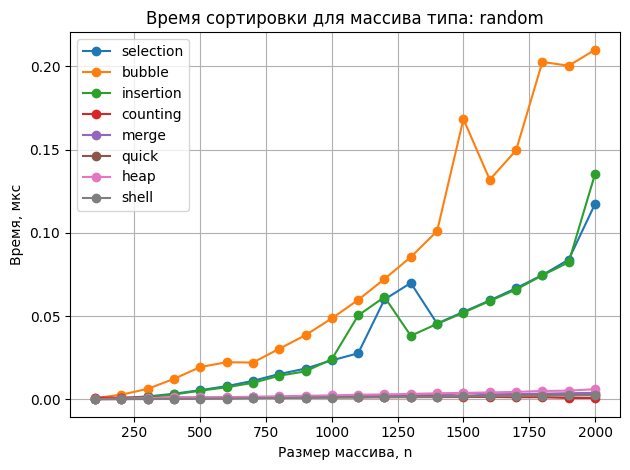

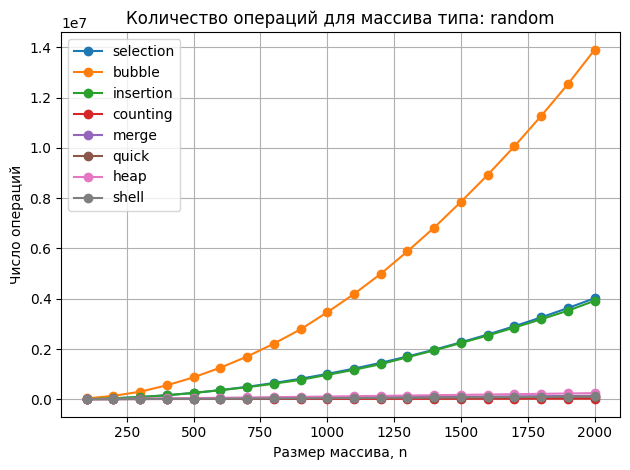

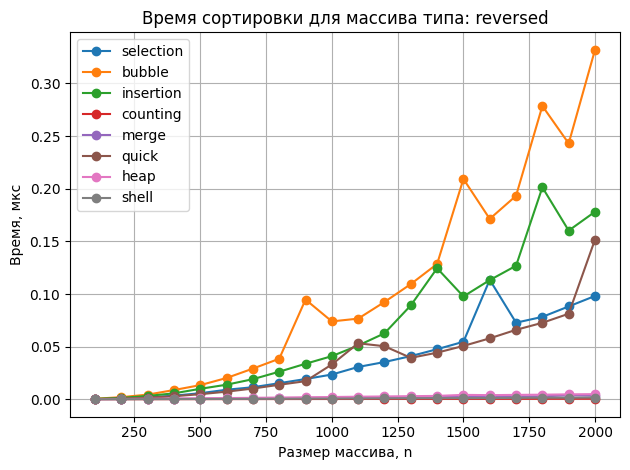

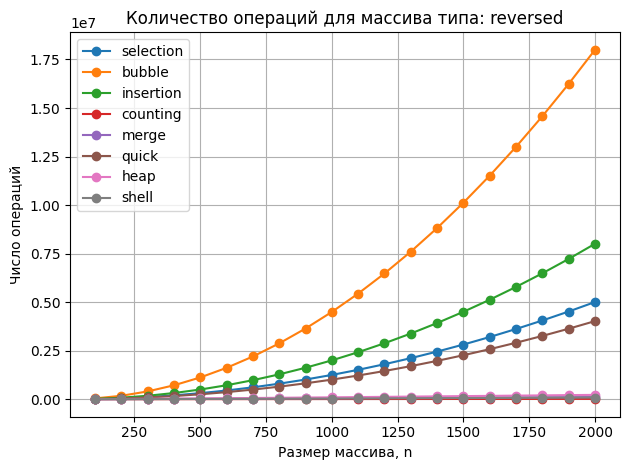

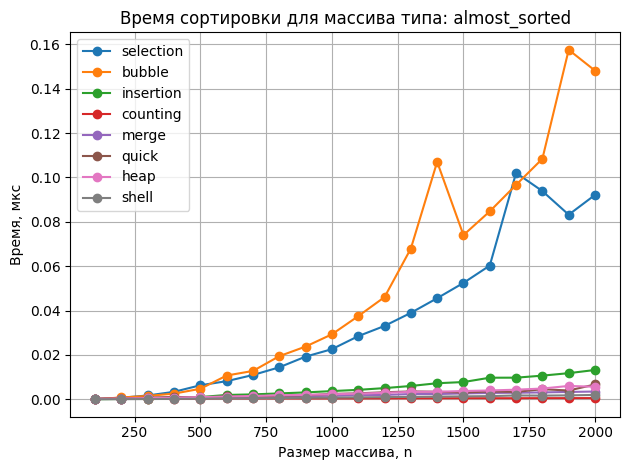

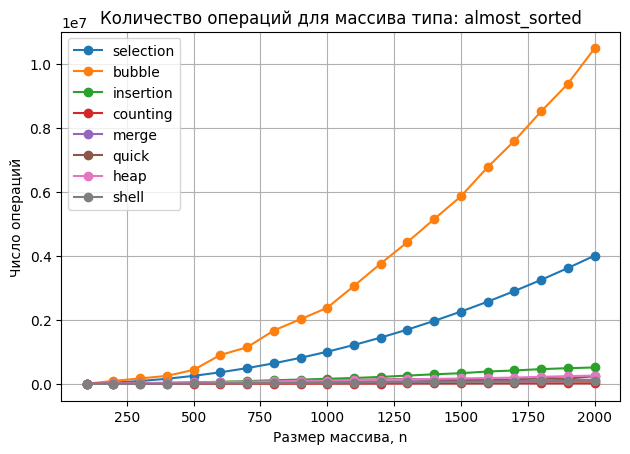

In [ ]:
import matplotlib.pyplot as plt

# I. Для каждого вида массива: график времени и график операций
for array_type_name in df["array_type"].unique():
    df_sub = df[df["array_type"] == array_type_name]
    plt.figure()
    for alg in df_sub["algorithm"].unique():
        dfa = df_sub[df_sub["algorithm"] == alg]
        plt.plot(dfa["n"], dfa["time_us"], marker="o", label=alg)
    plt.xlabel("Размер массива, n")
    plt.ylabel("Время, мкс")
    plt.title(f"Время сортировки для массива типа: {array_type_name}")
    plt.legend()
    plt.grid(True)
    plt.tight_layout()

    # График операций
    plt.figure()
    for alg in df_sub["algorithm"].unique():
        dfa = df_sub[df_sub["algorithm"] == alg]
        plt.plot(dfa["n"], dfa["ops"], marker="o", label=alg)
    plt.xlabel("Размер массива, n")
    plt.ylabel("Число операций")
    plt.title(f"Количество операций для массива типа: {array_type_name}")
    plt.legend()
    plt.grid(True)
    plt.tight_layout()

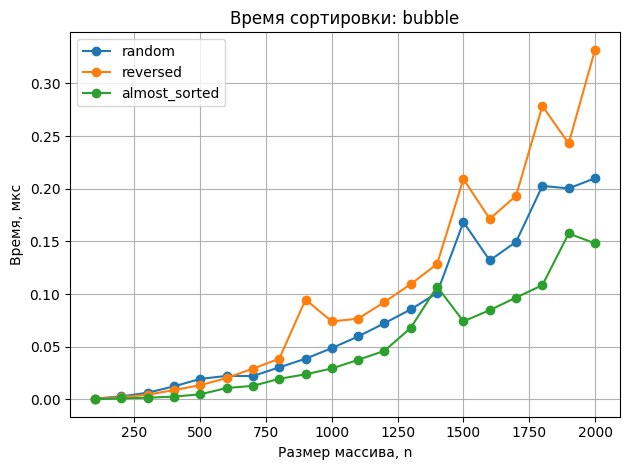

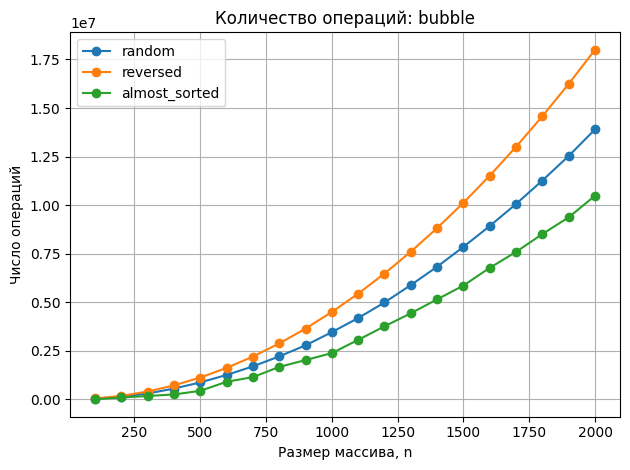

In [ ]:
import matplotlib.pyplot as plt

# II. Для каждого алгоритма
alg_name = "bubble"
df_alg = df[df["algorithm"] == alg_name]

# Время
plt.figure()
for array_type_name in df_alg["array_type"].unique():
    dfa = df_alg[df_alg["array_type"] == array_type_name]
    plt.plot(dfa["n"], dfa["time_us"], marker="o", label=array_type_name)

plt.xlabel("Размер массива, n")
plt.ylabel("Время, мкс")
plt.title(f"Время сортировки: {alg_name}")
plt.legend()
plt.grid(True)
plt.tight_layout()

# Операции
plt.figure()
for array_type_name in df_alg["array_type"].unique():
    dfa = df_alg[df_alg["array_type"] == array_type_name]
    plt.plot(dfa["n"], dfa["ops"], marker="o", label=array_type_name)

plt.xlabel("Размер массива, n")
plt.ylabel("Число операций")
plt.title(f"Количество операций: {alg_name}")
plt.legend()
plt.grid(True)
plt.tight_layout()


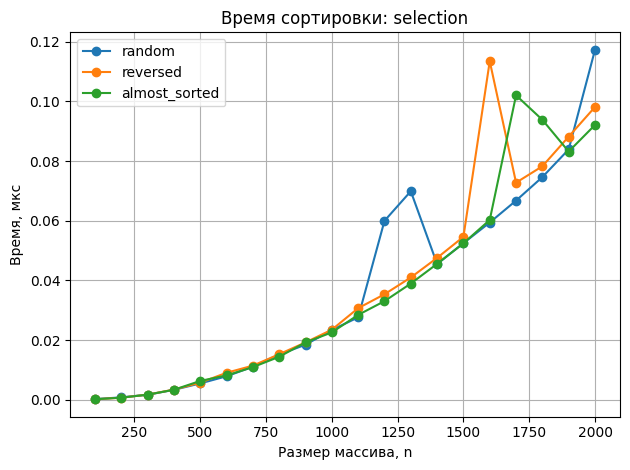

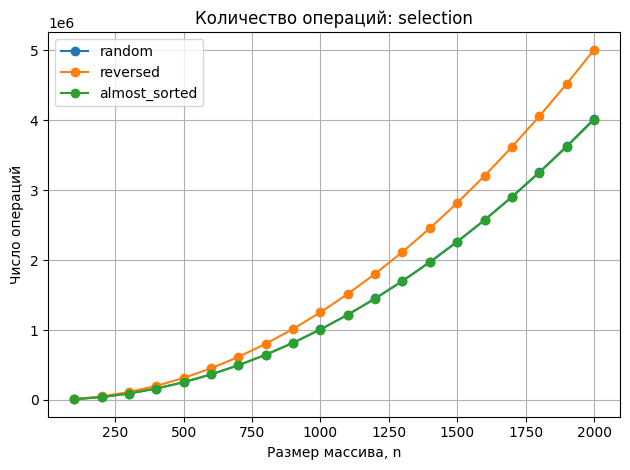

In [ ]:
alg_name = "selection"
df_alg = df[df["algorithm"] == alg_name]

# Время
plt.figure()
for array_type_name in df_alg["array_type"].unique():
    dfa = df_alg[df_alg["array_type"] == array_type_name]
    plt.plot(dfa["n"], dfa["time_us"], marker="o", label=array_type_name)

plt.xlabel("Размер массива, n")
plt.ylabel("Время, мкс")
plt.title(f"Время сортировки: {alg_name}")
plt.legend()
plt.grid(True)
plt.tight_layout()

# Операции
plt.figure()
for array_type_name in df_alg["array_type"].unique():
    dfa = df_alg[df_alg["array_type"] == array_type_name]
    plt.plot(dfa["n"], dfa["ops"], marker="o", label=array_type_name)

plt.xlabel("Размер массива, n")
plt.ylabel("Число операций")
plt.title(f"Количество операций: {alg_name}")
plt.legend()
plt.grid(True)
plt.tight_layout()

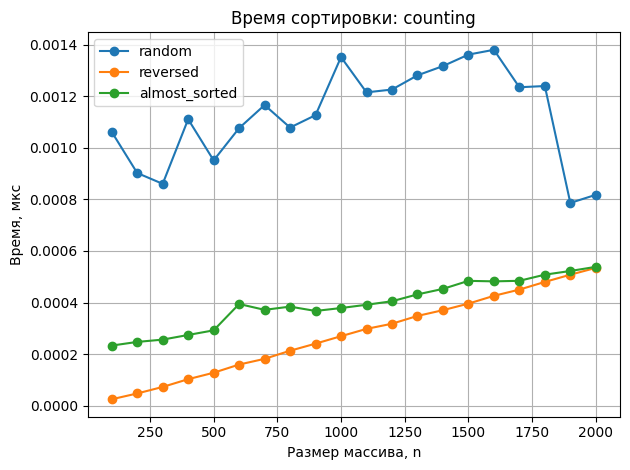

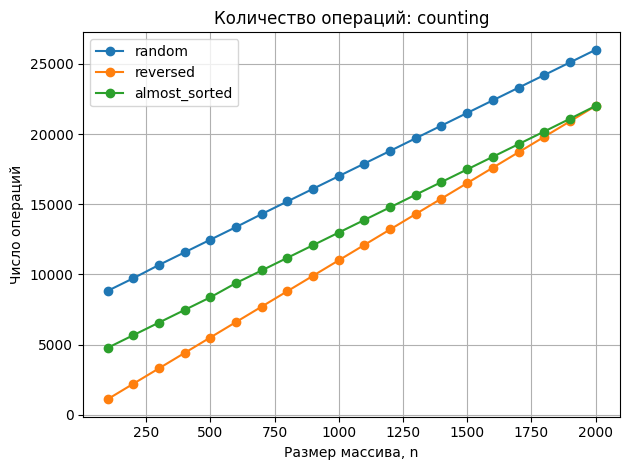

In [ ]:
alg_name = "counting"
df_alg = df[df["algorithm"] == alg_name]

# Время
plt.figure()
for array_type_name in df_alg["array_type"].unique():
    dfa = df_alg[df_alg["array_type"] == array_type_name]
    plt.plot(dfa["n"], dfa["time_us"], marker="o", label=array_type_name)

plt.xlabel("Размер массива, n")
plt.ylabel("Время, мкс")
plt.title(f"Время сортировки: {alg_name}")
plt.legend()
plt.grid(True)
plt.tight_layout()

# Операции
plt.figure()
for array_type_name in df_alg["array_type"].unique():
    dfa = df_alg[df_alg["array_type"] == array_type_name]
    plt.plot(dfa["n"], dfa["ops"], marker="o", label=array_type_name)

plt.xlabel("Размер массива, n")
plt.ylabel("Число операций")
plt.title(f"Количество операций: {alg_name}")
plt.legend()
plt.grid(True)
plt.tight_layout()

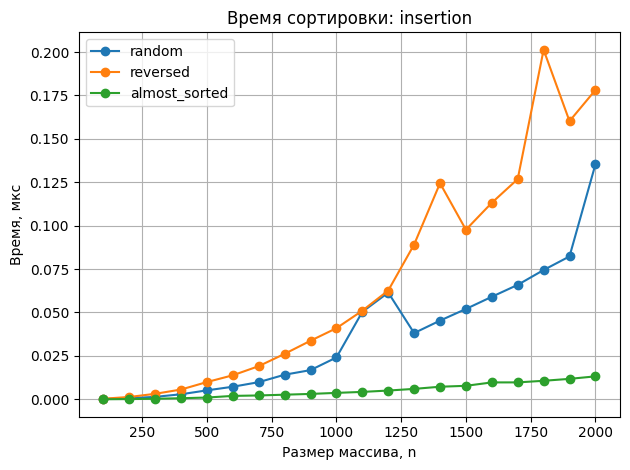

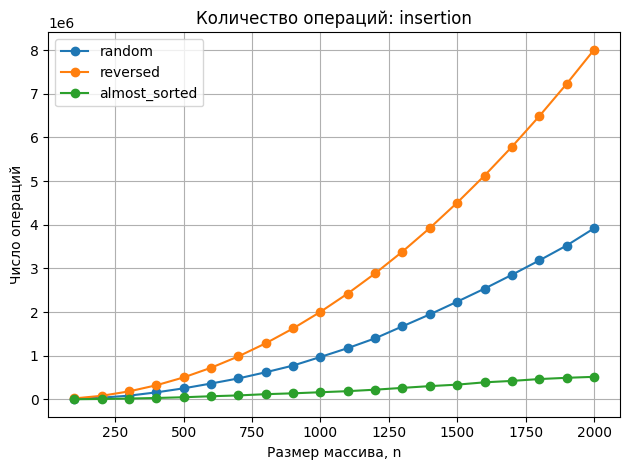

In [ ]:
alg_name = "insertion"
df_alg = df[df["algorithm"] == alg_name]

# Время
plt.figure()
for array_type_name in df_alg["array_type"].unique():
    dfa = df_alg[df_alg["array_type"] == array_type_name]
    plt.plot(dfa["n"], dfa["time_us"], marker="o", label=array_type_name)

plt.xlabel("Размер массива, n")
plt.ylabel("Время, мкс")
plt.title(f"Время сортировки: {alg_name}")
plt.legend()
plt.grid(True)
plt.tight_layout()

# Операции
plt.figure()
for array_type_name in df_alg["array_type"].unique():
    dfa = df_alg[df_alg["array_type"] == array_type_name]
    plt.plot(dfa["n"], dfa["ops"], marker="o", label=array_type_name)

plt.xlabel("Размер массива, n")
plt.ylabel("Число операций")
plt.title(f"Количество операций: {alg_name}")
plt.legend()
plt.grid(True)
plt.tight_layout()

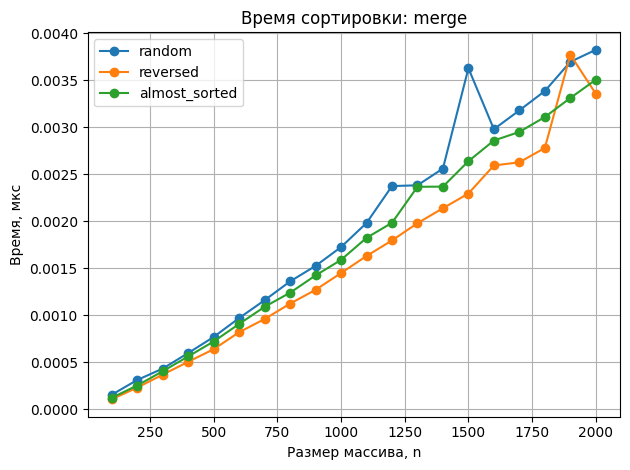

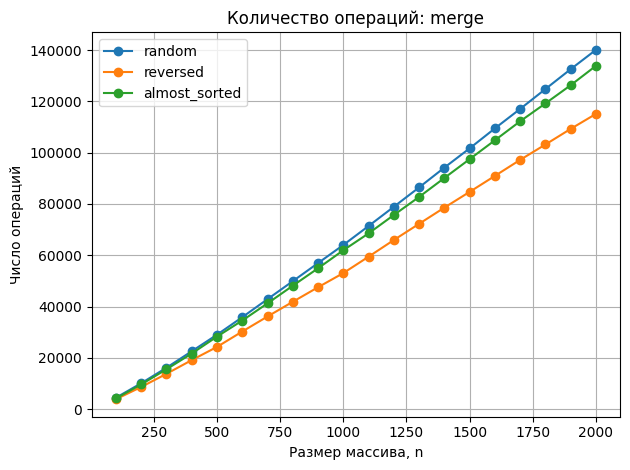

In [ ]:
alg_name = "merge"
df_alg = df[df["algorithm"] == alg_name]

# Время
plt.figure()
for array_type_name in df_alg["array_type"].unique():
    dfa = df_alg[df_alg["array_type"] == array_type_name]
    plt.plot(dfa["n"], dfa["time_us"], marker="o", label=array_type_name)

plt.xlabel("Размер массива, n")
plt.ylabel("Время, мкс")
plt.title(f"Время сортировки: {alg_name}")
plt.legend()
plt.grid(True)
plt.tight_layout()

# Операции
plt.figure()
for array_type_name in df_alg["array_type"].unique():
    dfa = df_alg[df_alg["array_type"] == array_type_name]
    plt.plot(dfa["n"], dfa["ops"], marker="o", label=array_type_name)

plt.xlabel("Размер массива, n")
plt.ylabel("Число операций")
plt.title(f"Количество операций: {alg_name}")
plt.legend()
plt.grid(True)
plt.tight_layout()

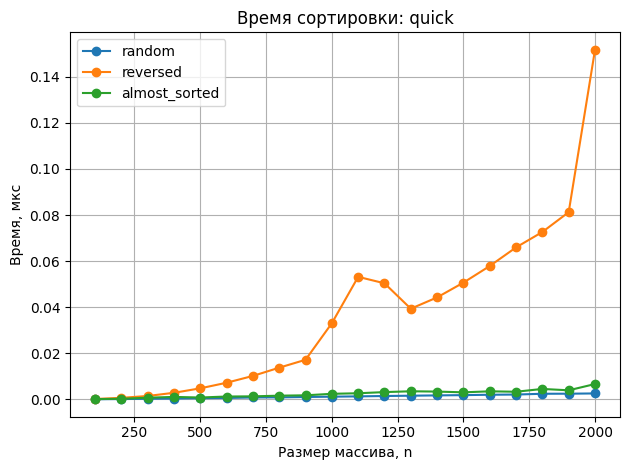

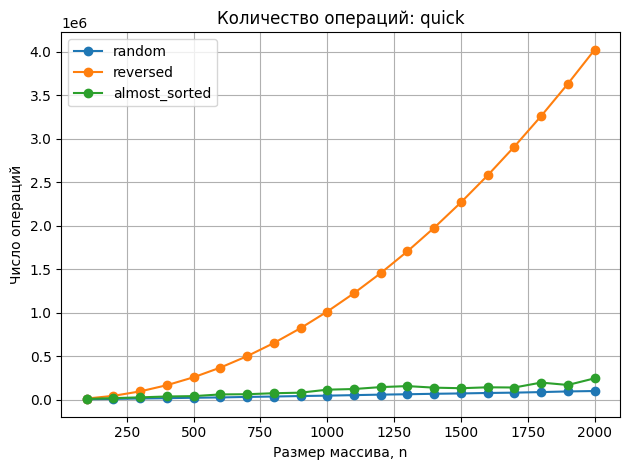

In [ ]:
alg_name = "quick"
df_alg = df[df["algorithm"] == alg_name]

# Время
plt.figure()
for array_type_name in df_alg["array_type"].unique():
    dfa = df_alg[df_alg["array_type"] == array_type_name]
    plt.plot(dfa["n"], dfa["time_us"], marker="o", label=array_type_name)

plt.xlabel("Размер массива, n")
plt.ylabel("Время, мкс")
plt.title(f"Время сортировки: {alg_name}")
plt.legend()
plt.grid(True)
plt.tight_layout()

# Операции
plt.figure()
for array_type_name in df_alg["array_type"].unique():
    dfa = df_alg[df_alg["array_type"] == array_type_name]
    plt.plot(dfa["n"], dfa["ops"], marker="o", label=array_type_name)

plt.xlabel("Размер массива, n")
plt.ylabel("Число операций")
plt.title(f"Количество операций: {alg_name}")
plt.legend()
plt.grid(True)
plt.tight_layout()

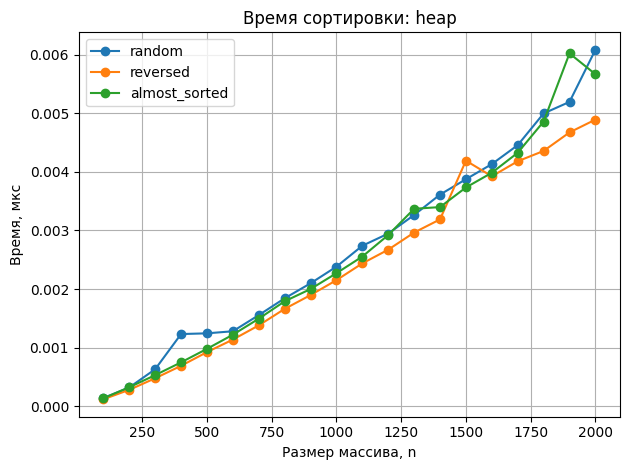

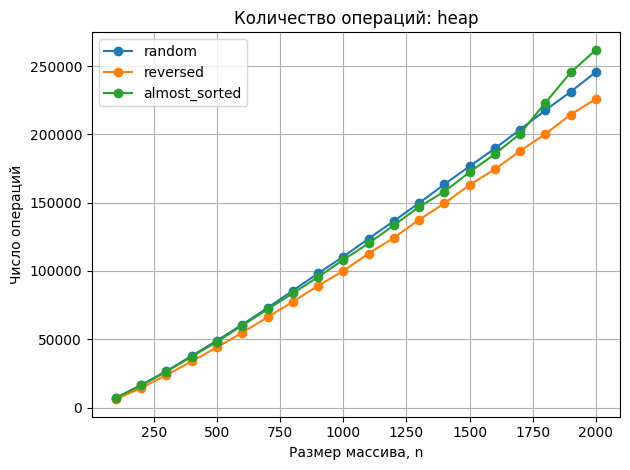

In [ ]:
alg_name = "heap"
df_alg = df[df["algorithm"] == alg_name]

# Время
plt.figure()
for array_type_name in df_alg["array_type"].unique():
    dfa = df_alg[df_alg["array_type"] == array_type_name]
    plt.plot(dfa["n"], dfa["time_us"], marker="o", label=array_type_name)

plt.xlabel("Размер массива, n")
plt.ylabel("Время, мкс")
plt.title(f"Время сортировки: {alg_name}")
plt.legend()
plt.grid(True)
plt.tight_layout()

# Операции
plt.figure()
for array_type_name in df_alg["array_type"].unique():
    dfa = df_alg[df_alg["array_type"] == array_type_name]
    plt.plot(dfa["n"], dfa["ops"], marker="o", label=array_type_name)

plt.xlabel("Размер массива, n")
plt.ylabel("Число операций")
plt.title(f"Количество операций: {alg_name}")
plt.legend()
plt.grid(True)
plt.tight_layout()

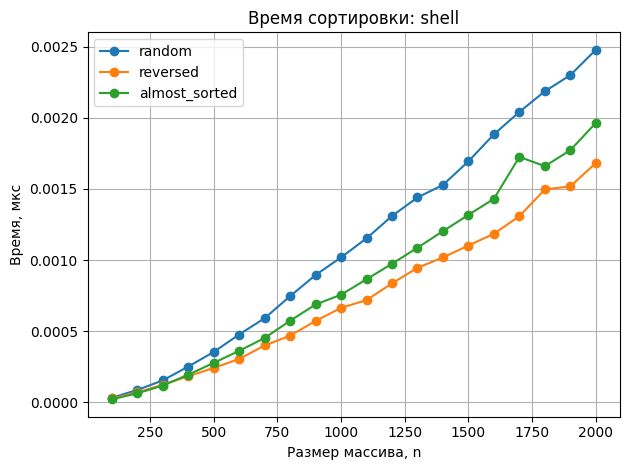

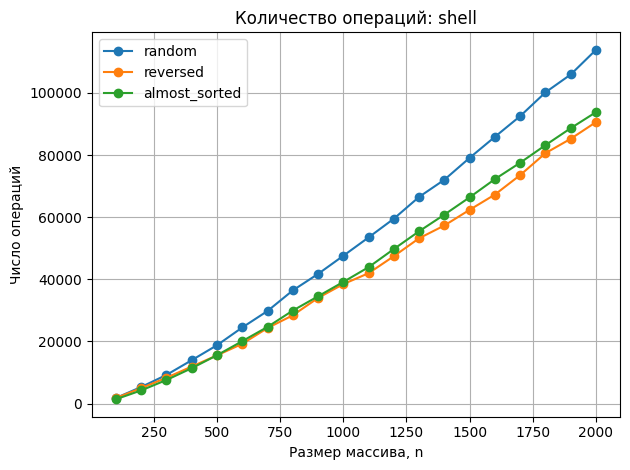

In [ ]:
alg_name = "shell"
df_alg = df[df["algorithm"] == alg_name]

# Время
plt.figure()
for array_type_name in df_alg["array_type"].unique():
    dfa = df_alg[df_alg["array_type"] == array_type_name]
    plt.plot(dfa["n"], dfa["time_us"], marker="o", label=array_type_name)

plt.xlabel("Размер массива, n")
plt.ylabel("Время, мкс")
plt.title(f"Время сортировки: {alg_name}")
plt.legend()
plt.grid(True)
plt.tight_layout()

# Операции
plt.figure()
for array_type_name in df_alg["array_type"].unique():
    dfa = df_alg[df_alg["array_type"] == array_type_name]
    plt.plot(dfa["n"], dfa["ops"], marker="o", label=array_type_name)

plt.xlabel("Размер массива, n")
plt.ylabel("Число операций")
plt.title(f"Количество операций: {alg_name}")
plt.legend()
plt.grid(True)
plt.tight_layout()

## **8. Анализ полученных результатов**

Заполните таблицу
| Алгоритм | Лучшая | Средняя | Худшая | Память | Устойчивость | Примечания |
|---|---|---|---|---|---|---|
| **Выбором** | O(n^2) | O(n^2) | O(n^2) | O(1) | - | Всегда n^2. Графики времени и числа операций для random, reversed и almost_sorted полностью сливаются в одну квадратичную параболу (за исключениев моментов выбросов). Алгоритм совершает одинаковое число сравнений независимо от характера входных данных.
| **Пузырьковая** | O(n) | O(n^2) | O(n^2) | O(1) | + | На графиках почти отсортированных данных (almost_sorted) видна практически горизонтальная линия — алгоритм адаптируется благодаря флагу оптимизации. При этом на random и reversed графиках наблюдается классическая тяжелая зависимость O(n^2).
| **Вставками** | O(n) | O(n^2) | O(n^2) | O(1) | + | Лучший случай на отсортированных данных близок к O(n), что чётко видно по почти плоскому графику almost_sorted. На random и reversed графиках кривые уходят в крутую параболу, подтверждая теоретическую сложность O(n^2). |
| **Подсчётом** | O(n+k) | O(n+k) | O(n+k) | O(k) | + | k — диапазон значений (в данном случае 4001). Графики операций для всех типов данных сливаются в прямую линию. На больших массивах этот алгоритм оказывается самым быстрым среди всех представленных. |
| **Слиянием** | O(n log n) | O(n log n) | O(n log n) | O(n) | + | Показывает абсолютную стабильность: графики для random, reversed и almost_sorted идут строго вместе, подтверждая независимость O(n log n) от исходного порядка элементов в массиве. |
| **Быстрая (Хоар)** | O(n log n) | O(n log n) | O(n^2) | O(log n) | - | Худший случай ярко проявляется на reversed массивах, где график числа операций резко уходит вверх по параболе O(n^2) из-за неудачного выбора опорного элемента. На random и almost_sorted алгоритм демонстрирует отличную скорость O(nlog n).|
| **Пирамидальная** | O(n log n) | O(n log n) | O(n log n) | O(1) | - | Гарантированно O(n log n) без доп. памяти. На reversed массивах алгоритм совершает даже чуть меньше операций, чем на random, из-за специфики изначального построения двоичной кучи. |
| **Шелла (Циур)** | O(n log n) | O(n^(4/3)) | O(n^(4/3)) | O(1) | - | По графикам видно, что алгоритм работает эффективнее всего на reversed и almost_sorted массивах, в то время как на случайных данных (random) число операций заметно выше. |

В пояснениях можно прямо указывать и делать отсылки к графикам из ваших экспериментов:

*На графике X видно, что на почти отсортированных данных Insertion Sort работает рядом с O(n), а Bubble всё ещё показывает квадратичную зависимость…*

Ответьте еще на вопросы:

**1. Почему выбросы есть?**

Выбросы в измерениях времени возникают из-за внешних факторов (планировщик ОС вытесняет процесс, срабатывает сборщик мусора Python, происходят кэш-промахи или переключения контекста).

**2. Почему мы делаем повторы при измерении времени?**

Одиночный запуск сортировки включает случайный шум от ОС и не только. При 20 повторах случайные выбросы сглаживаются, и среднее значение намного точнее отражает реальную производительность алгоритма.

## **9. Что сделано**
- Реализованы 8 алгоритмов сортировки (выбором, пузырьковая, вставками, подсчётом, слиянием, быстрая Хоара, пирамидальная, Шелла).
- Для каждого — версия с счётчиком элементарных операций.
- Генерация 3 типов массивов (случайный, обратный, почти отсортированный).
- Корректное измерение времени работы с помощью timeit с 20 повторами.
- Сохранение результатов в csv-формате.
- Набор I: 6 графиков (3 типа и 2 метрики, все 8 алгоритмов).
- Набор II: 16 графиков (8 алгоритмов и 2 метрики, все 3 типа).
- Таблица асимптотик с анализом и ответами на вопросы.




## **10. Что не сделано**

-  TimSort не реализован

## **11. Шкала и критерии оценки**

Вы можете получить **10 баллов**, где:

### 1. Алгоритмы сортировки — 3 балла

**Базовые алгоритмы (8 шт.)**

* Сортировка выбором
* Пузырьковая (с флагом, лучший случай O(n))
* Простые вставки
* Подсчётом (устойчивая)
* Слиянием
* Быстрая (первый опорный, Хоар)
* Пирамидальная
* Шелла (Циур)

**Оценка:**

* **3.0 балла** — все 8 реализованы корректно (не портят массив, действительно сортируют, нет лишней логики внутри сортировки).
* **2.0** — 1–2 алгоритма отсутствуют или работают неправильно.
* **1.0** — 3-4 алгоритма отсутствуют или работают неправильно.
* **0** — реализовано сильно меньше половины или есть серьёзные ошибки.

Важно! сортировка должна быть отделена от генерации массивов и измерений, чтобы её можно было честно вызывать в экспериментах.

### 2. Измерение времени и операций — 1 балл

* Используются **универсальные функции измерения**, типа `measure_sort_time` и `measure_sort_ops`.
* Время меряется через `timeit` / `perf_counter`, **без включения генерации массивов**.
* Есть **повторы (20–100)** и усреднение.
* Время **никогда не равно 0 на реальных размерах**.
* Подсчёт элементарных операций сделан в самих алгоритмах (счётчики в коде) и **одинаков по смыслу** для разных алгоритмов.

**Оценка:**

* **1.0 балла** — корректная методика: повторы, только сортировка в замере, счётчики операций работают и используются.
* **0–0.5** — измерения времени/операций либо отсутствуют, либо сделаны некорректно, что-то не до конца сделано: мало повторов, или в замер случайно попадает генерация массивов, или операции считаются только в части алгоритмов..

### 3. Типы массивов и структура эксперимента — 1 балл

Минимум 3 типа массивов:

* случайный `[0; 4000]`
* почти отсортированный
* обратно отсортированный

Размеры: **от 100 до 2000 с шагом 100**.
Для каждого вида массива и каждого алгоритма:

* генерируется **один эталонный массив** максимального размера,
* для измерений берутся **префиксы** и копируются в рабочий массив.

**Оценка:**

* **1.0 балл** — все типы массивов реализованы, эталонный массив не портится, размеры и шаг соблюдены, циклы устроены логично (вид массива → алгоритм → n → повторы).
* **0** — не все типы массивов, или бывает “пересортировка уже отсортированного”, или диапазон/шаги частично нарушены, один тип массива, неполный диапазон размерностей, структура эксперимента хаотичная.

### 4. Таблицы и CSV / DataFrame -- 1 балл

* Результаты собраны в **единый DataFrame** или несколько таблиц.
* Есть поля типа: `n, algorithm, array_type, time, ops`.
* Данные **сохраняются** в CSV.

### 5. Графики — 2 балла

Соблюдены требования:

* Набор I: для каждого **вида массива** — графики с кривыми для разных алгоритмов (в полном решении — 9/10 кривых; в демо хотя бы несколько).
* Набор II: для каждого **алгоритма** — кривые по типам массивов.
* Подписаны оси:

  * X — размер массива `n`;
  * Y — время (нс/мкс/мс) или число операций.
* Есть **название графика** и **легенда**.
* Масштабы выбраны так, чтобы что-то было видно (при необходимости логарифмическая шкала или разделение “медленные/быстрые”).

**Оценка:**

* **2 балла** — есть оба набора графиков (время + операции), всё подписано, легенды читаемы, сравнивать удобно.
* **1.0** — графики есть, но чего-то не хватает (часть не подписана, легенда неясна, нет графиков для операций или для части алгоритмов).
* **0** — графиков нет или они “слепые”.

### 6. Анализ и таблица асимптотик — 2 балла

* Заполнена таблица:

  * Лучшая / средняя / худшая сложность
  * Память
  * Устойчивость
  * Примечания: когда алгоритм хорош/плох, на каких данных и как это видно по графикам.

* В анализе:

  * объяснено, **почему есть выбросы**;
  * почему нужны **повторы при измерении**;
  * есть отсылки к конкретным графикам (например: “на графике для random видно, что quicksort ≈ n log n, а bubble — квадратичный рост”).

**Оценка:**

* **1.5 балла** — таблица заполнена адекватно, асимптотика правильная, комментарии осмысленные и связаны с экспериментами.
* **0.5–1.0** — таблица есть, но часть полей неверна или комментарии очень поверхностные.
* **0** — анализа почти нет.


### 7. Код, аккуратность, воспроизводимость (если нет, штраф 1 балл)

* Код аккуратен, без каких-то жёстких копипаст, с минимально необходимыми комментариями.
* Есть `random.seed(...)` для воспроизводимости экспериментов.
* Нет лишних `print` в больших циклах, сортировки не делают ничего кроме сортировки.

**Оценка:**

* **0.5 балла** — видно, что код можно читать и запускать: он структурирован, не превращён в кашу.
* **0–0.25** — код очень грязный, тяжело понять, что где происходит.